Análise dos Microdados do ENEM – Goiás

Disciplina: CESAR  
Curso:Ciência de Dados / IA  
Instituição: UNISO  

Este notebook apresenta uma análise exploratória dos microdados do ENEM,
com foco nos participantes do estado de Goiás.


# Importação de bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Carregamento dos dados

In [10]:
df_go_resultados = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"]
df_go_participantes = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]

# Visão inicial

Não tratada

In [6]:
import pandas as pd

df_resultados = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_participantes = pd.read_csv(
    "../dados/bruto/PARTICIPANTES_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_resultados.shape, df_participantes.shape


((4332944, 42), (4332944, 38))

# Limpeza e Tratamento

Selecionar apenas colunas necessárias

In [7]:
coluna_notas = [
    "SG_UF_PROVA",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_CH",
    "NU_NOTA_CN",
    "NU_NOTA_REDACAO",
]

df = df_resultados[coluna_notas].copy()
print ("Base Inicial:", df.shape)

Base Inicial: (4332944, 6)


Colocando nomes legíveis

In [8]:
df = df.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

print("Colunas renomeadas:")
print(df.columns)

Colunas renomeadas:
Index(['SG_UF_PROVA', 'Linguagens', 'Matemática', 'Ciências Humanas',
       'Ciências da Natureza', 'Redação'],
      dtype='object')


In [11]:
df.to_csv("notebooks/comparacao_go_br.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'notebooks'

Remoção de registros duplicados

In [12]:
duplicados = df.duplicated().sum()
print("Quantidade de registros duplicados:", duplicados)
df = df.drop_duplicates ()
print ("Base apóes remover duplicados:", df.shape)

Quantidade de registros duplicados: 1151156
Base apóes remover duplicados: (3181788, 6)


Remoção de ausentes

In [13]:
print("\nValores nulos antes da remoção:")
print(df.isnull().sum())

df = df.dropna(subset=[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
])

print("\nValores nulos após remoção:")
print(df.isnull().sum())

print("Base após remover NaN:", df.shape)


Valores nulos antes da remoção:
SG_UF_PROVA                  0
Linguagens               14842
Matemática              176888
Ciências Humanas         14842
Ciências da Natureza    176888
Redação                  14842
dtype: int64

Valores nulos após remoção:
SG_UF_PROVA             0
Linguagens              0
Matemática              0
Ciências Humanas        0
Ciências da Natureza    0
Redação                 0
dtype: int64
Base após remover NaN: (2990085, 6)


Garantir intervalo das notas (0 a 1000)

In [14]:
colunas_notas_numericas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação",
]

for col in colunas_notas_numericas:
    df = df[(df[col] >= 0) & (df[col] <= 1000)]
print("Base após validar o intervalo das notas:", df.shape)

Base após validar o intervalo das notas: (2990085, 6)


Conferindo limpeza

In [15]:
print("\nResumo estatístico após limpeza:")
print(df.describe())

print("\nLimpeza concluída.")


Resumo estatístico após limpeza:
         Linguagens    Matemática  Ciências Humanas  Ciências da Natureza  \
count  2.990085e+06  2.990085e+06      2.990085e+06          2.990085e+06   
mean   5.266230e+02  5.270825e+02      5.142141e+02          4.940272e+02   
std    6.865276e+01  1.141688e+02      9.155267e+01          7.898593e+01   
min    0.000000e+00  0.000000e+00      0.000000e+00          0.000000e+00   
25%    4.867000e+02  4.313000e+02      4.502000e+02          4.315000e+02   
50%    5.334000e+02  4.992000e+02      5.194000e+02          4.885000e+02   
75%    5.736000e+02  6.110000e+02      5.785000e+02          5.503000e+02   
max    7.958000e+02  9.619000e+02      8.197000e+02          8.672000e+02   

            Redação  
count  2.990085e+06  
mean   6.346677e+02  
std    2.090931e+02  
min    0.000000e+00  
25%    5.200000e+02  
50%    6.400000e+02  
75%    8.000000e+02  
max    1.000000e+03  

Limpeza concluída.


graficos das limpezas

C:\Users\Alan\AppData\Local\Temp\ipykernel_13364\2943507445.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dados["Etapa"], y=dados["Quantidade"], palette="Blues")


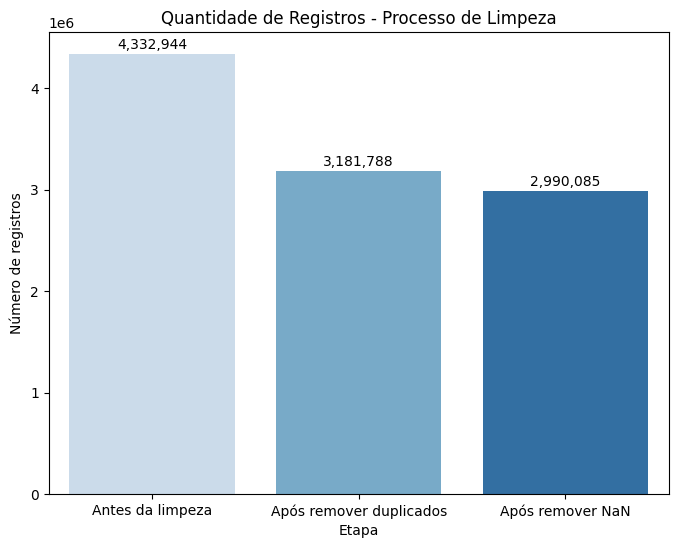

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados
dados = {
    "Etapa": ["Antes da limpeza", "Após remover duplicados", "Após remover NaN"],
    "Quantidade": [4332944, 3181788, 2990085]
}

# Gráfico
plt.figure(figsize=(8,6))
sns.barplot(x=dados["Etapa"], y=dados["Quantidade"], palette="Blues")

# Título e rótulos
plt.title("Quantidade de Registros - Processo de Limpeza")
plt.ylabel("Número de registros")
plt.xlabel("Etapa")

# Valores em cima das barras
for i, v in enumerate(dados["Quantidade"]):
    plt.text(i, v + 50000, f"{v:,}", ha="center", fontsize=10)

plt.show()


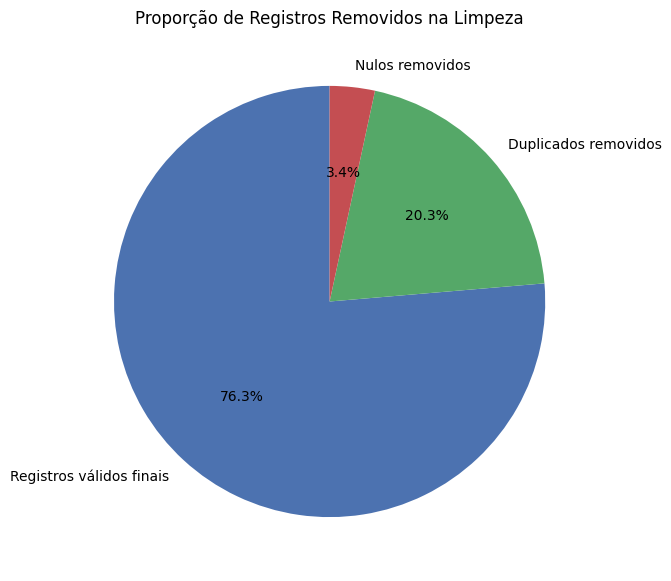

In [17]:
# Proporção removida
valores = [4332944, 4332944-3181788, 3181788-2990085]
labels = ["Registros válidos finais", "Duplicados removidos", "Nulos removidos"]

plt.figure(figsize=(7,7))
plt.pie(valores, labels=labels, autopct="%1.1f%%", startangle=90, colors=["#4c72b0","#55a868","#c44e52"])
plt.title("Proporção de Registros Removidos na Limpeza")
plt.show()


C:\Users\Alan\AppData\Local\Temp\ipykernel_13364\346667497.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dados["Situação"], y=dados["Quantidade"], palette="Set2")


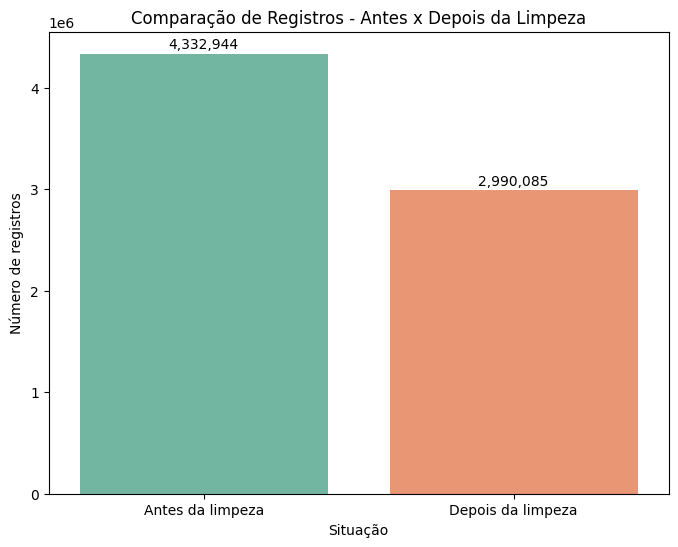

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Quantidades
antes = 4332944   # total original
depois = 2990085  # após remover duplicados e NaN

# DataFrame para plotagem
dados = {
    "Situação": ["Antes da limpeza", "Depois da limpeza"],
    "Quantidade": [antes, depois]
}

plt.figure(figsize=(8,6))
sns.barplot(x=dados["Situação"], y=dados["Quantidade"], palette="Set2")

# Título e rótulos
plt.title("Comparação de Registros - Antes x Depois da Limpeza")
plt.ylabel("Número de registros")
plt.xlabel("Situação")

# Adiciona valores em cima das barras
for i, v in enumerate(dados["Quantidade"]):
    plt.text(i, v + 50000, f"{v:,}", ha="center", fontsize=10)

plt.show()


# 3. Análise Comparativa — Goiás vs Brasil

Nesta seção, comparamos o desempenho médio dos participantes do ENEM 2024
do estado de Goiás (GO) com a média nacional (Brasil),
considerando as cinco áreas avaliadas.

Garantindo dados limpos

In [19]:
colunas_notas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

df_limpo = df.dropna(subset=colunas_notas)

In [20]:
print(df.columns)

Index(['SG_UF_PROVA', 'Linguagens', 'Matemática', 'Ciências Humanas',
       'Ciências da Natureza', 'Redação'],
      dtype='object')


Separar Go do Brasil

In [21]:
df_go = df[df["SG_UF_PROVA"] == "GO"]
df_br = df  # Brasil inteiro

tamanho dos dados

In [22]:
print("Tamanho GO:", df_go.shape)
print("Tamanho Brasil:", df_br.shape)

Tamanho GO: (102473, 6)
Tamanho Brasil: (2990085, 6)


calculo das médias

In [23]:
colunas_notas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

media_go = df_go[colunas_notas].mean()
media_br = df_br[colunas_notas].mean()

medias = pd.DataFrame({
    "GO": media_go,
    "Brasil": media_br
}).round(2)

medias

,GO,Brasil
Linguagens,525.05,526.62
Matemática,527.51,527.08
Ciências Humanas,513.12,514.21
Ciências da Natureza,494.66,494.03
Redação,659.54,634.67


Desvio padrão das notas

In [24]:
desvio_go = df_go[colunas_notas].std()
desvio_br = df_br[colunas_notas].std()

df_desvios = pd.DataFrame({
    "Desvio_GO": desvio_go,
    "Desvio_BR": desvio_br
})

df_desvios.round(2)

,Desvio_GO,Desvio_BR
Linguagens,66.60,68.65
Matemática,113.11,114.17
Ciências Humanas,89.76,91.55
Ciências da Natureza,78.85,78.99
Redação,200.86,209.09


In [25]:
print(df_resultados.columns)

Index(['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC',
       'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA',
       'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_PRESENCA_CN',
       'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN',
       'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
       'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH',
       'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN',
       'TX_GABARITO_CH', 'TX_GABARITO_LC', 'TX_GABARITO_MT',
       'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3',
       'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'],
      dtype='object')


In [26]:
print(df_participantes.columns)

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA',
       'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Q001', 'Q002',
       'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011',
       'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020',
       'Q021', 'Q022', 'Q023'],
      dtype='object')


# Análise de renda — GO vs Brasil
### Distribuição de renda familiar dos participantes

Nesta seção analisamos a distribuição das faixas de renda familiar dos participantes
do ENEM 2024, comparando o estado de Goiás com o conjunto nacional.

In [27]:
# Filtrar participantes de Goiás
df_part_go = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]

# Distribuição percentual de renda no Brasil
renda_br = df_participantes["Q006"].value_counts(normalize=True).sort_index() * 100

# Distribuição percentual de renda em Goiás
renda_go = df_part_go["Q006"].value_counts(normalize=True).sort_index() * 100

# Criar tabela comparativa
comparacao_renda = pd.DataFrame({
    "GO_%": renda_go,
    "BR_%": renda_br
}).fillna(0)

comparacao_renda.round(2)

,GO_%,BR_%
Q006,,
A,70.74,72.45
B,29.26,27.55


In [28]:
mapa_renda = {
    "A": "Baixa renda",
    "B": "Renda um pouco maior"
}

comparacao_renda.index = comparacao_renda.index.map(mapa_renda)
comparacao_renda

,GO_%,BR_%
Q006,,
Baixa renda,70.737242,72.446021
Renda um pouco maior,29.262758,27.553979


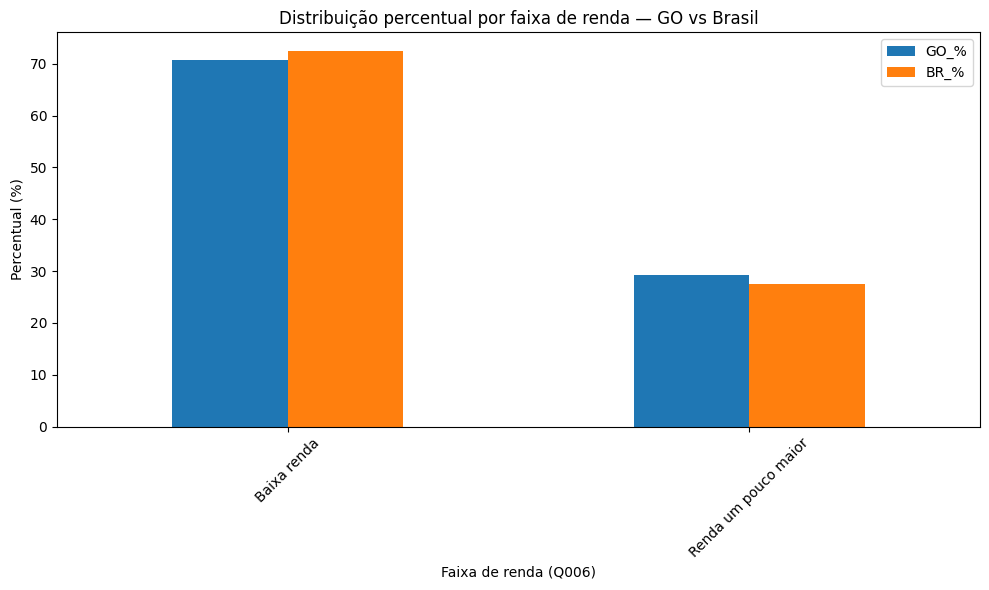

In [29]:
import matplotlib.pyplot as plt

comparacao_renda.plot(kind="bar", figsize=(10,6))

plt.title("Distribuição percentual por faixa de renda — GO vs Brasil")
plt.ylabel("Percentual (%)")
plt.xlabel("Faixa de renda (Q006)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Resumo - A análise da variável renda familiar mostra que a maioria dos participantes do ENEM pertence às faixas de menor renda. Em Goiás, aproximadamente 70,74% dos participantes estão na categoria A, enquanto no Brasil esse percentual é de 72,45%. A categoria B representa 29,26% dos participantes em Goiás e 27,55% no Brasil. Esses resultados indicam que o perfil socioeconômico dos participantes do estado é bastante semelhante ao observado no cenário nacional, com predominância de candidatos provenientes de famílias de menor renda.

A predominância de participantes nas faixas de menor renda reforça o papel do ENEM como principal porta de entrada para o ensino superior público no Brasil, especialmente para estudantes provenientes de contextos socioeconômicos menos favorecidos.

# Análise por raça — GO vs Brasil
### Distribuição por raça/cor

Também analisamos a distribuição de raça/cor declarada pelos participantes
do ENEM, comparando o estado de Goiás com a distribuição nacional.

In [30]:
# Distribuição percentual no Brasil
raca_br = df_participantes["TP_COR_RACA"].value_counts(normalize=True).sort_index() * 100

# Distribuição percentual em Goiás
raca_go = df_part_go["TP_COR_RACA"].value_counts(normalize=True).sort_index() * 100

# Criar tabela comparativa
comparacao_raca = pd.DataFrame({
    "GO_%": raca_go,
    "BR_%": raca_br
}).fillna(0)

comparacao_raca.round(2)

,GO_%,BR_%
TP_COR_RACA,,
0,1.49,1.17
1,38.74,41.35
2,11.25,12.34
3,45.92,43.01
4,2.18,1.44
5,0.42,0.69


In [31]:
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
    6: "Não informado"
}

comparacao_raca.index = comparacao_raca.index.map(mapa_raca)

comparacao_raca

,GO_%,BR_%
TP_COR_RACA,,
Não declarado,1.490493,1.168536
Branca,38.738935,41.354885
Preta,11.246510,12.339255
Parda,45.924794,43.006256
Amarela,2.179177,1.440568
Indígena,0.420090,0.690501


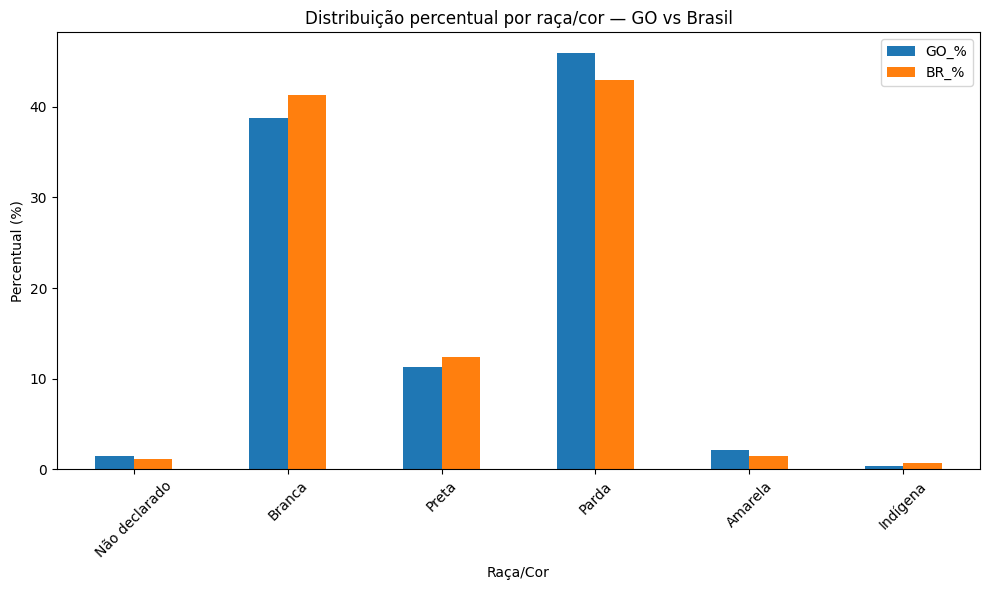

In [32]:
comparacao_raca.plot(kind="bar", figsize=(10,6))

plt.title("Distribuição percentual por raça/cor — GO vs Brasil")
plt.ylabel("Percentual (%)")
plt.xlabel("Raça/Cor")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Resumindo - A análise da variável raça/cor indica que a maioria dos participantes do ENEM pertence às categorias parda e branca, tanto em Goiás quanto no Brasil. Em Goiás, os participantes pardos representam aproximadamente 45,9%, enquanto os brancos correspondem a 38,7%. No cenário nacional, esses valores são 43,0% e 41,3%, respectivamente. As demais categorias apresentam menor participação, com destaque para os participantes pretos, que representam cerca de 11% em Goiás e 12% no Brasil. De modo geral, observa-se que a distribuição racial dos participantes em Goiás segue um padrão semelhante ao observado nacionalmente, com pequenas diferenças percentuais entre os grupos.

In [33]:
df_resultados = df_resultados.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

Histograma das notas

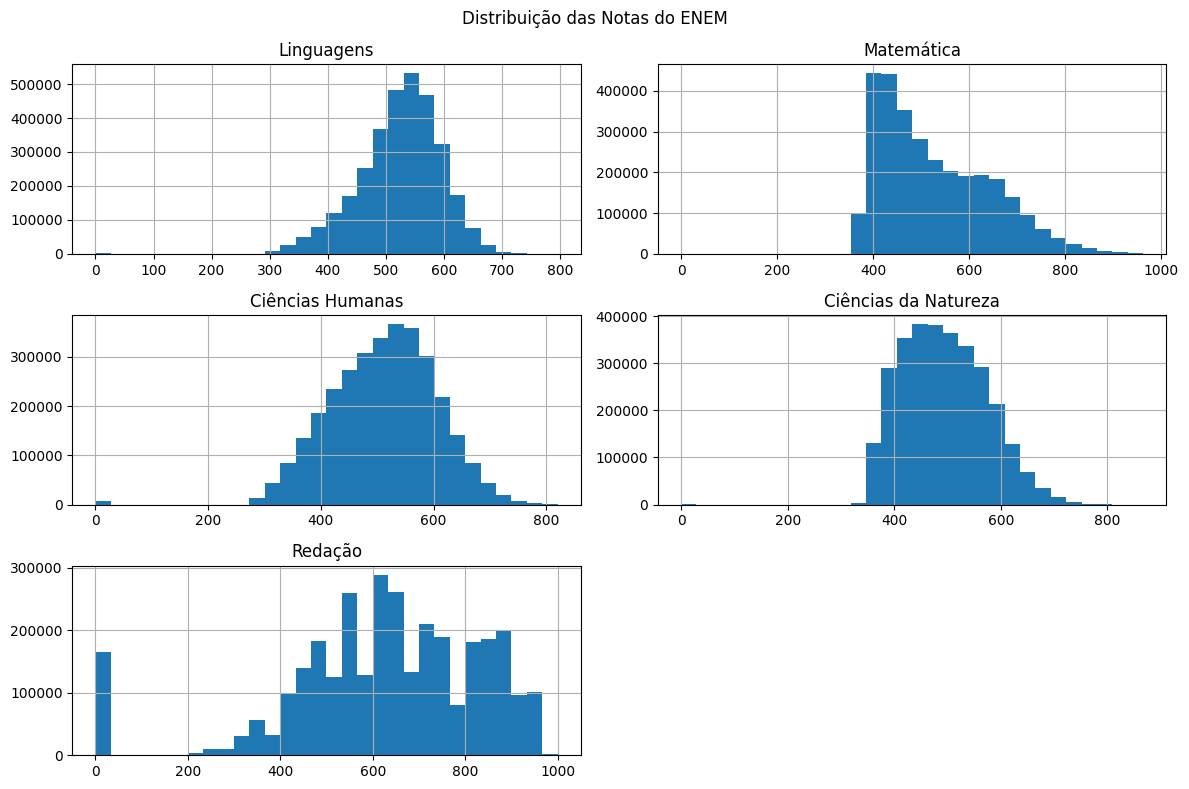

In [34]:
import matplotlib.pyplot as plt

df_resultados[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].hist(bins=30, figsize=(12,8))

plt.suptitle("Distribuição das Notas do ENEM")
plt.tight_layout()
plt.show()

Matriz de correlação das notas

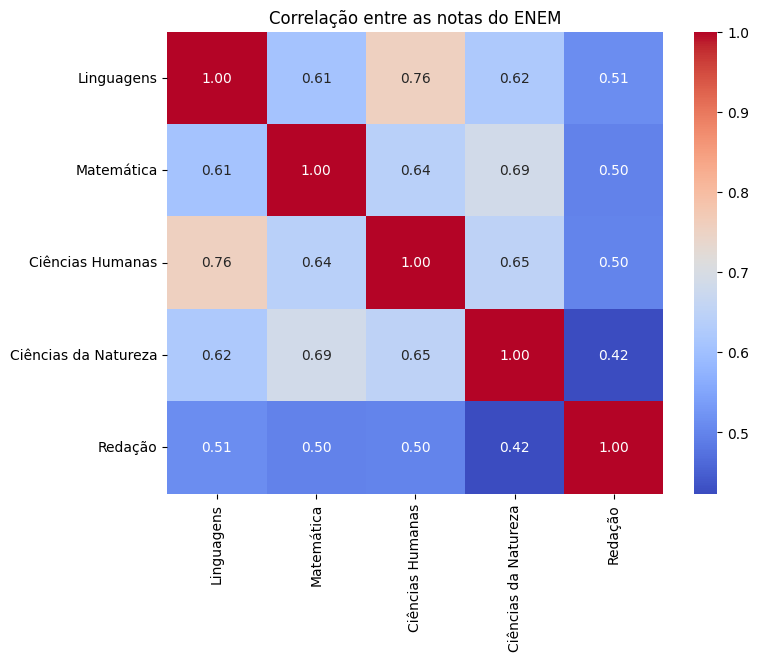

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_resultados[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlação entre as notas do ENEM")
plt.show()

In [36]:
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

In [37]:
df_participantes["RACA"] = df_participantes["TP_COR_RACA"].map(mapa_raca)

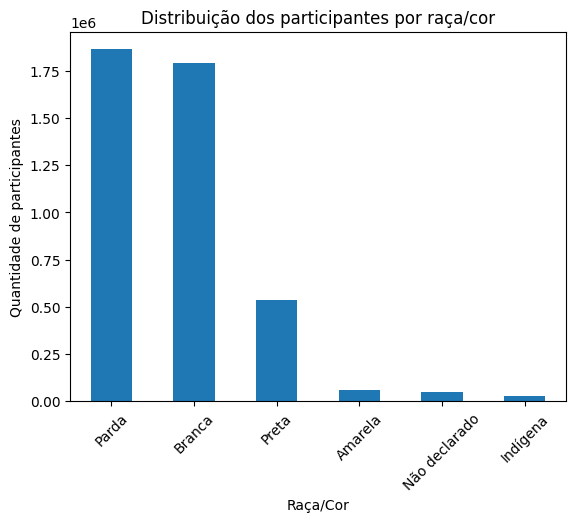

In [38]:
import matplotlib.pyplot as plt

df_participantes["RACA"].value_counts().plot(kind="bar")

plt.title("Distribuição dos participantes por raça/cor")
plt.xlabel("Raça/Cor")
plt.ylabel("Quantidade de participantes")

plt.xticks(rotation=45)

plt.show()

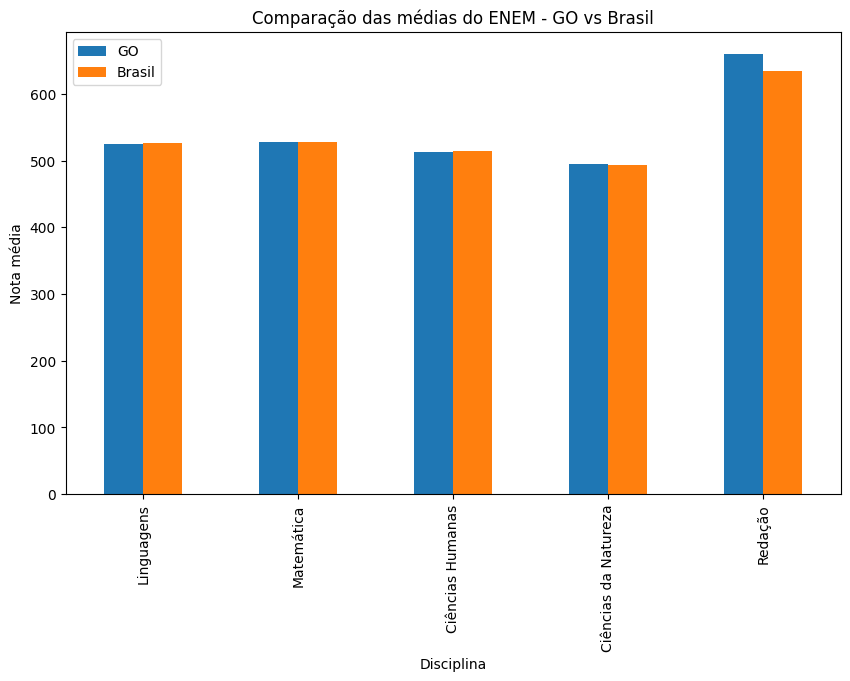

In [39]:
medias.plot(kind="bar", figsize=(10,6))

plt.title("Comparação das médias do ENEM - GO vs Brasil")
plt.ylabel("Nota média")
plt.xlabel("Disciplina")

plt.show()

In [40]:
%who

antes	 col	 coluna_notas	 colunas_notas	 colunas_notas_numericas	 comparacao_raca	 comparacao_renda	 corr	 dados	 
depois	 desvio_br	 desvio_go	 df	 df_br	 df_desvios	 df_go	 df_go_participantes	 df_go_resultados	 
df_limpo	 df_part_go	 df_participantes	 df_resultados	 duplicados	 i	 labels	 mapa_raca	 mapa_renda	 
media_br	 media_go	 medias	 np	 pd	 plt	 raca_br	 raca_go	 renda_br	 
renda_go	 sns	 v	 valores	 


In [41]:
df_br = df_resultados.copy()

In [42]:
df_go = df_go_resultados.copy()

# Análise — Tipo de Escola (ENEM: Goiás vs Brasil)

Investigar se o tipo de escola (Pública ou Privada) influencia o desempenho dos estudantes nas diferentes áreas do ENEM, comparando:

Estado de Goiás

Brasil

Essa análise permite identificar desigualdades educacionais e verificar se o padrão observado em Goiás segue ou não a tendência nacional.

In [43]:
colunas_escola = [
    "SG_UF_PROVA",
    "TP_DEPENDENCIA_ADM_ESC",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_CH",
    "NU_NOTA_CN",
    "NU_NOTA_REDACAO"
]

df_escola = df_resultados[colunas_escola].copy()

df_escola = df_escola.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

KeyError: "['NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_REDACAO'] not in index"

In [ ]:
df_go_escola = df_escola[df_escola["SG_UF_PROVA"] == "GO"].copy()
df_br_escola = df_escola.copy()

NameError: name 'df_escola' is not defined

In [ ]:
mapa_escola = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

df_go_escola["TP_DEPENDENCIA_ADM_ESC"] = df_go_escola["TP_DEPENDENCIA_ADM_ESC"].map(mapa_escola)
df_br_escola["TP_DEPENDENCIA_ADM_ESC"] = df_br_escola["TP_DEPENDENCIA_ADM_ESC"].map(mapa_escola)

NameError: name 'df_go_escola' is not defined

# media das notas por escola (Goias)

In [ ]:
media_go_escola = df_go_escola.groupby("TP_DEPENDENCIA_ADM_ESC")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media_go_escola.round(2))

NameError: name 'df_go_escola' is not defined

In [ ]:
import matplotlib.pyplot as plt

ax = media_go_escola.plot(kind="bar", figsize=(10,6))

plt.title("Média das notas por tipo de escola — Goiás")
plt.ylabel("Nota média")
plt.xlabel("Tipo de escola")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

NameError: name 'media_go_escola' is not defined

# Media Brasil tipo de escola

In [ ]:
media_br_escola = df_br_escola.groupby("TP_DEPENDENCIA_ADM_ESC")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media_br_escola.round(2))

NameError: name 'df_br_escola' is not defined

In [ ]:
ax = media_br_escola.plot(kind="bar", figsize=(10,6))

plt.title("Média das notas por tipo de escola — Brasil")
plt.ylabel("Nota média")
plt.xlabel("Tipo de escola")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

NameError: name 'media_br_escola' is not defined

# Média das notas por SEXO (Goias)

In [ ]:
df_sexo = pd.concat(
    [
        df_resultados.reset_index(drop=True),
        df_participantes[["TP_SEXO"]].reset_index(drop=True)
    ],
    axis=1
)

In [ ]:
df_sexo = df_sexo.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

In [ ]:
df_sexo = df_sexo.dropna()

In [ ]:
df_go_sexo = df_sexo[df_sexo["SG_UF_PROVA"] == "GO"].copy()
df_br_sexo = df_sexo.copy()

In [ ]:
mapa_sexo = {
    "M": "Masculino",
    "F": "Feminino"
}

df_go_sexo["TP_SEXO"] = df_go_sexo["TP_SEXO"].map(mapa_sexo)
df_br_sexo["TP_SEXO"] = df_br_sexo["TP_SEXO"].map(mapa_sexo)

In [ ]:
media_go_sexo = df_go_sexo.groupby("TP_SEXO")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media_go_sexo.round(2))

           Linguagens  Matemática  Ciências Humanas  Ciências da Natureza  \
TP_SEXO                                                                     
Feminino        515.6      518.50            501.33                484.76   
Masculino       515.4      519.71            500.40                485.74   

           Redação  
TP_SEXO             
Feminino    649.20  
Masculino   648.79  


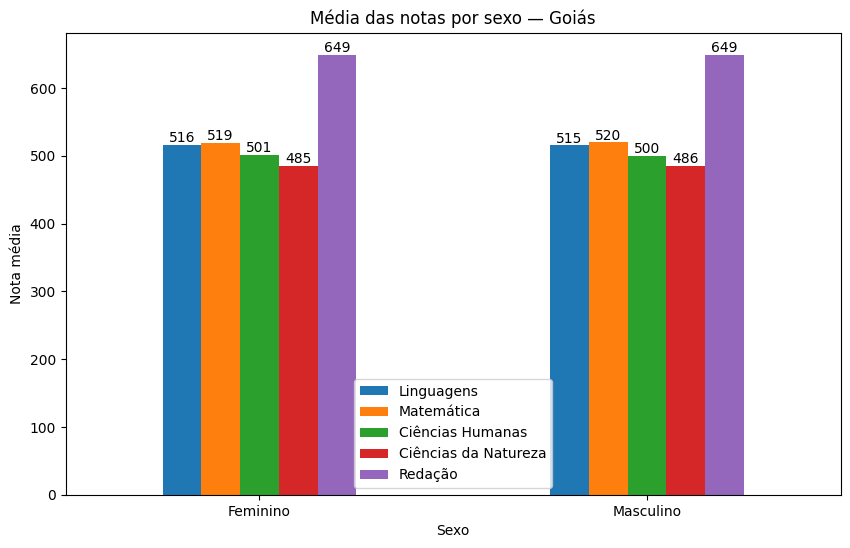

In [ ]:
import matplotlib.pyplot as plt

ax = media_go_sexo.plot(kind="bar", figsize=(10,6))

plt.title("Média das notas por sexo — Goiás")
plt.ylabel("Nota média")
plt.xlabel("Sexo")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

quantidade de homens e mulheres

In [ ]:
df_go_sexo["TP_SEXO"].value_counts()

TP_SEXO
Feminino     26655
Masculino    17425
Name: count, dtype: int64

# Média das notas por SEXO (Brasil)

In [ ]:
media_br_sexo = df_br_sexo.groupby("TP_SEXO")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media_br_sexo.round(2))

           Linguagens  Matemática  Ciências Humanas  Ciências da Natureza  \
TP_SEXO                                                                     
Feminino       518.84      520.65            503.81                486.66   
Masculino      518.78      520.72            503.55                486.66   

           Redação  
TP_SEXO             
Feminino    630.32  
Masculino   630.13  


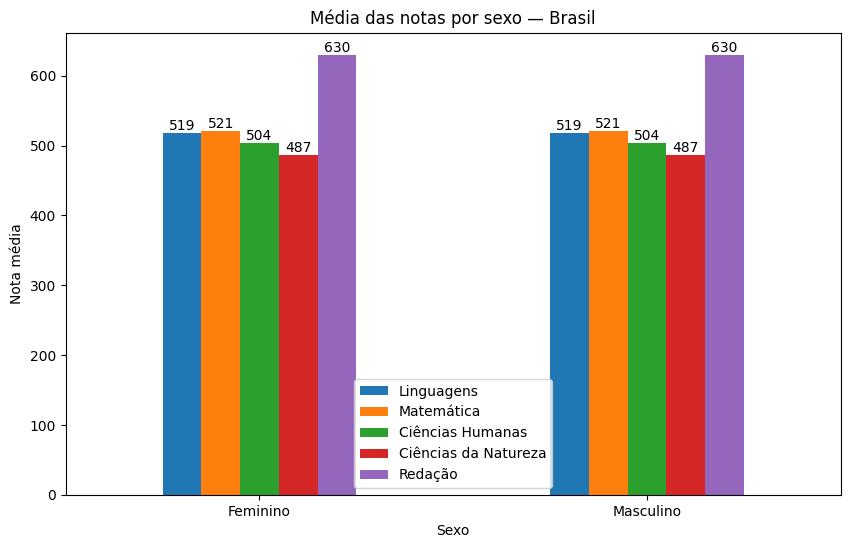

In [ ]:
ax = media_br_sexo.plot(kind="bar", figsize=(10,6))

plt.title("Média das notas por sexo — Brasil")
plt.ylabel("Nota média")
plt.xlabel("Sexo")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

quantidade de homens e mulheres

In [ ]:
print(df_sexo["TP_SEXO"].value_counts(dropna=False))

TP_SEXO
F    723614
M    469818
Name: count, dtype: int64


Perguntas de 1-4(ja vou deixar no bolco de notas.)

In [ ]:

df_escola["Tipo_Escola"] = df_escola["TP_DEPENDENCIA_ADM_ESC"].map({
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
})

NameError: name 'df_escola' is not defined

In [ ]:
df_escola["Tipo_Escola"].value_counts()

NameError: name 'df_escola' is not defined

In [ ]:
df_escola["Rede"] = df_escola["Tipo_Escola"].replace({
    "Federal": "Pública",
    "Estadual": "Pública",
    "Municipal": "Pública",
    "Privada": "Privada"
})

NameError: name 'df_escola' is not defined

In [ ]:
df_escola["Rede"].value_counts()

NameError: name 'df_escola' is not defined

In [ ]:
media_rede = df_escola.groupby("Rede")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media_rede.round(2))

NameError: name 'df_escola' is not defined

In [ ]:
gap = media_rede.loc["Privada"] - media_rede.loc["Pública"]

print(gap.round(2))

NameError: name 'media_rede' is not defined

In [ ]:
desvio_rede = df_escola.groupby("Rede")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].std()

print(desvio_rede.round(2))

NameError: name 'df_escola' is not defined

perguntas de 4-8

In [45]:
desvio_go = df_go[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].std()

print(desvio_go.round(2))

KeyError: "None of [Index(['Linguagens', 'Matemática', 'Ciências Humanas', 'Ciências da Natureza',\n       'Redação'],\n      dtype='object')] are in the [columns]"

In [46]:
mediana_go = df_go[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].median()

comparacao = pd.DataFrame({
    "Média": media_go,
    "Mediana": mediana_go
})

print(comparacao.round(2))

KeyError: "None of [Index(['Linguagens', 'Matemática', 'Ciências Humanas', 'Ciências da Natureza',\n       'Redação'],\n      dtype='object')] are in the [columns]"

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_go["Matemática"], bins=50, kde=True)

plt.title("Distribuição das notas de Matemática — Goiás")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

KeyError: 'Matemática'

<Figure size 800x500 with 0 Axes>

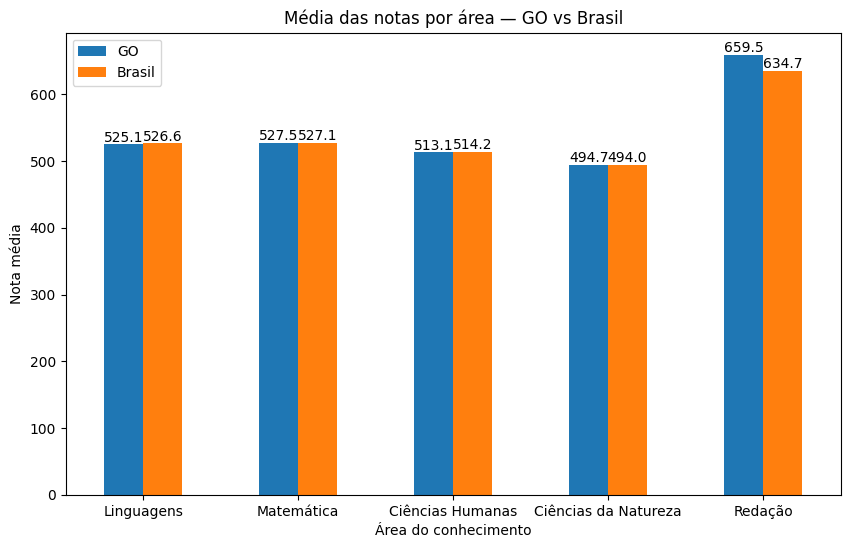

In [48]:
import matplotlib.pyplot as plt

comparacao_medias = pd.DataFrame({
    "GO": media_go,
    "Brasil": media_br
})

ax = comparacao_medias.plot(kind="bar", figsize=(10,6))

plt.title("Média das notas por área — GO vs Brasil")
plt.ylabel("Nota média")
plt.xlabel("Área do conhecimento")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

In [50]:
import matplotlib.pyplot as plt

df_go[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].hist(bins=30, figsize=(12,8))

plt.suptitle("Distribuição das Notas do ENEM — Goiás")
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['Linguagens', 'Matemática', 'Ciências Humanas', 'Ciências da Natureza',\n       'Redação'],\n      dtype='object')] are in the [columns]"

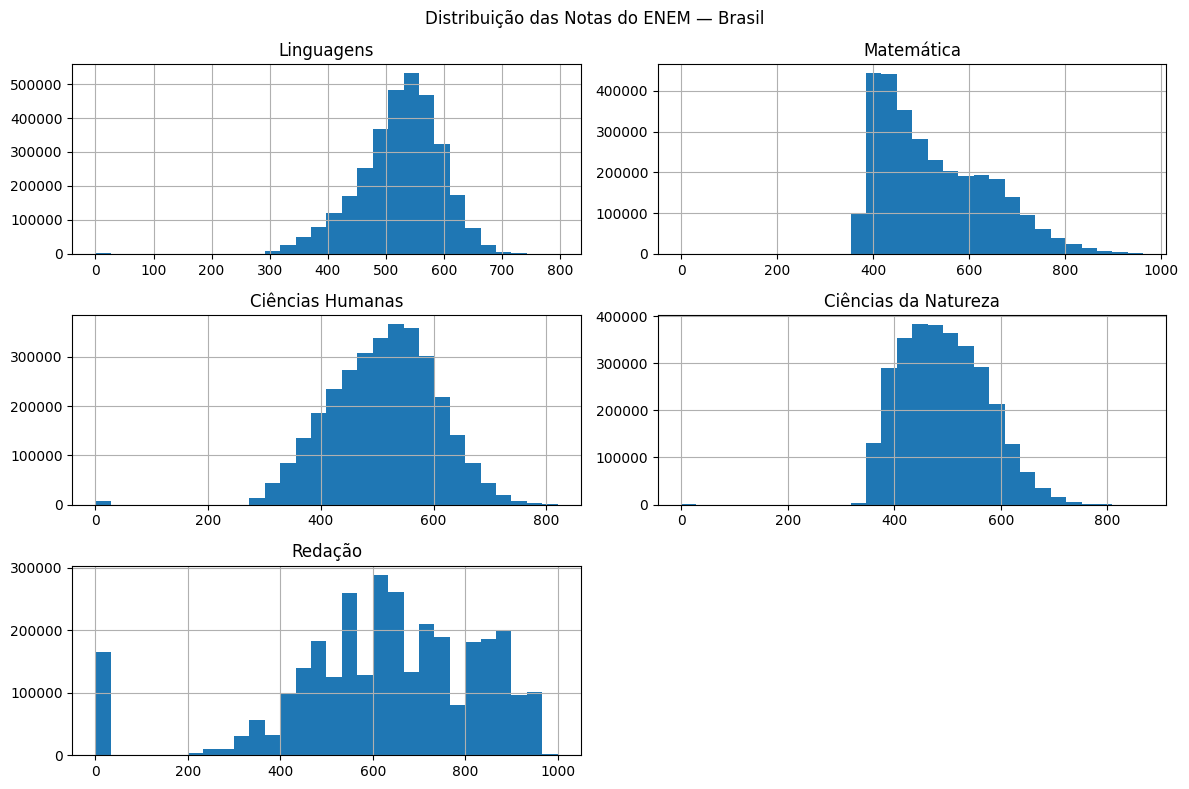

In [51]:
df_br[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].hist(bins=30, figsize=(12,8))

plt.suptitle("Distribuição das Notas do ENEM — Brasil")
plt.tight_layout()
plt.show()

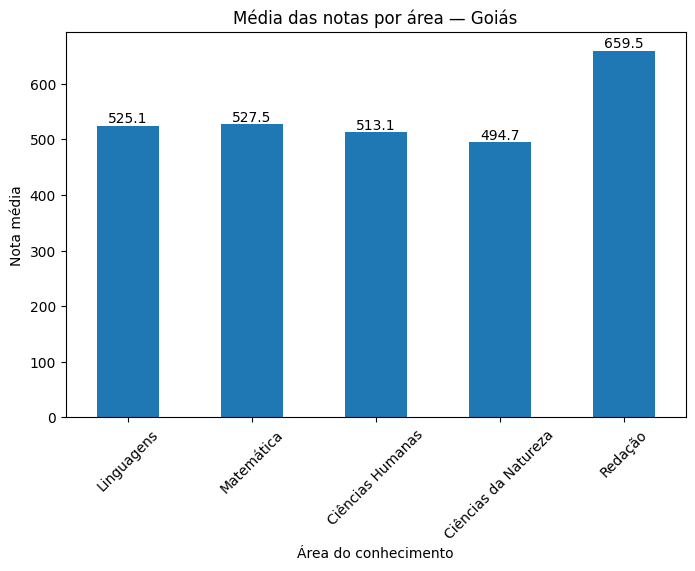

In [52]:
import matplotlib.pyplot as plt

ax = media_go.plot(kind="bar", figsize=(8,5))

plt.title("Média das notas por área — Goiás")
plt.ylabel("Nota média")
plt.xlabel("Área do conhecimento")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

In [53]:
desvio_go = df_go[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].std()

ax = desvio_go.plot(kind="bar", figsize=(8,5), color="orange")

plt.title("Desvio padrão das notas por área — Goiás")
plt.ylabel("Desvio padrão")
plt.xlabel("Área")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

KeyError: "None of [Index(['Linguagens', 'Matemática', 'Ciências Humanas', 'Ciências da Natureza',\n       'Redação'],\n      dtype='object')] are in the [columns]"

In [ ]:
media_rede = df_escola.groupby("Rede")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media_rede.round(2))

NameError: name 'df_escola' is not defined

In [ ]:
ax = media_rede.plot(kind="bar", figsize=(8,5))

plt.title("Média das notas por rede de ensino")
plt.ylabel("Nota média")
plt.xlabel("Rede")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

NameError: name 'media_rede' is not defined

In [ ]:
ax = gap.plot(kind="bar", figsize=(8,5), color="red")

plt.title("Diferença de notas entre rede privada e pública")
plt.ylabel("Diferença de nota")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

In [ ]:
ax = desvio_rede.plot(kind="bar", figsize=(8,5))

plt.title("Desvio padrão das notas por rede de ensino")
plt.ylabel("Desvio padrão")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

In [ ]:
comparacao_medias = pd.DataFrame({
    "GO": media_go,
    "Brasil": media_br
})

ax = comparacao_medias.plot(kind="bar", figsize=(8,5))

plt.title("Média das notas — GO vs Brasil")
plt.ylabel("Nota média")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

comparacao_medias = pd.DataFrame({
    "GO": media_go,
    "Brasil": media_br
})

ax = comparacao_medias.plot(kind="bar", figsize=(10,6), width=0.8)

plt.title("Média das notas por área — Goiás vs Brasil")
plt.ylabel("Nota média")
plt.xlabel("Área do conhecimento")
plt.xticks(rotation=45)

for p in ax.patches:
    altura = p.get_height()
    
    ax.annotate(f"{altura:.1f}",
                (p.get_x() + p.get_width()/2, altura - 15),
                ha='center', va='top',
                rotation=90, fontsize=8, color='black')

plt.tight_layout()
plt.show()

In [ ]:
ax = desvio_go.plot(kind="bar", figsize=(8,5), color="orange")

plt.title("Desvio padrão das notas por área — Goiás")
plt.ylabel("Desvio padrão")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

In [ ]:
ax = comparacao.plot(kind="bar", figsize=(8,5))

plt.title("Comparação entre média e mediana")
plt.ylabel("Valor")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_go["Matemática"], bins=30, kde=True)

plt.title("Distribuição das notas de Matemática — Goiás")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

ax = comparacao.plot(kind="bar", figsize=(10,6), width=0.8)

plt.title("Comparação entre média e mediana — Goiás")
plt.ylabel("Valor da nota")
plt.xlabel("Área do conhecimento")
plt.xticks(rotation=45)

for p in ax.patches:
    altura = p.get_height()
    
    ax.annotate(f"{altura:.1f}",
                (p.get_x() + p.get_width()/2, altura - 15),
                ha='center', va='top',
                rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ax = media_rede.plot(kind="bar", figsize=(10,6), width=0.8)

plt.title("Média das notas por rede de ensino")
plt.ylabel("Nota média")
plt.xlabel("Rede")

for p in ax.patches:
    altura = p.get_height()
    
    ax.annotate(f"{altura:.1f}",
                (p.get_x() + p.get_width()/2, altura - 20),
                ha='center', va='top',
                rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ax = media_go_escola.plot(kind="bar", figsize=(10,6), width=0.8)

plt.title("Média das notas por tipo de escola — Goiás")
plt.ylabel("Nota média")
plt.xlabel("Tipo de escola")

for p in ax.patches:
    altura = p.get_height()
    
    ax.annotate(f"{altura:.1f}",
                (p.get_x() + p.get_width()/2, altura - 20),
                ha='center', va='top',
                rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
ax = media_br_escola.plot(kind="bar", figsize=(10,6), width=0.8)

plt.title("Média das notas por tipo de escola — Brasil")
plt.ylabel("Nota média")
plt.xlabel("Tipo de escola")

for p in ax.patches:
    altura = p.get_height()
    
    ax.annotate(f"{altura:.1f}",
                (p.get_x() + p.get_width()/2, altura - 20),
                ha='center', va='top',
                rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)

In [ ]:
import os
print(os.getcwd())

In [ ]:
df_final = df[[
    "SG_UF_PROVA",
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].copy()

df_final = df_final.rename(columns={
    "SG_UF_PROVA": "UF"
})

df_final = df_final.drop_duplicates()
df_final = df_final.dropna()

df_final.to_csv("../dados/tratado/enem_tratado.csv", index=False)

print("Base criada:", df_final.shape)

In [ ]:
import os
import pandas as pd

colunas_escola = [
    "SG_UF_PROVA",
    "TP_DEPENDENCIA_ADM_ESC",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_CH",
    "NU_NOTA_CN",
    "NU_NOTA_REDACAO"
]

df_escola = df_resultados[colunas_escola].copy()

df_escola = df_escola.rename(columns={
    "SG_UF_PROVA": "UF",
    "TP_DEPENDENCIA_ADM_ESC": "Tipo_Escola",
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

mapa_escola = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

df_escola["Tipo_Escola"] = df_escola["Tipo_Escola"].map(mapa_escola)

df_escola = df_escola.drop_duplicates()
df_escola = df_escola.dropna(subset=[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação",
    "Tipo_Escola"
])

os.makedirs("../dados/tratado", exist_ok=True)
df_escola.to_csv("../dados/tratado/enem_escola.csv", index=False)

print("Base escola criada:", df_escola.shape)
print(df_escola.head())

In [ ]:
print(df_resultados.columns)

Index(['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC',
       'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA',
       'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_PRESENCA_CN',
       'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN',
       'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'Ciências da Natureza',
       'Ciências Humanas', 'Linguagens', 'Matemática', 'TX_RESPOSTAS_CN',
       'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA',
       'TX_GABARITO_CN', 'TX_GABARITO_CH', 'TX_GABARITO_LC', 'TX_GABARITO_MT',
       'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3',
       'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'Redação'],
      dtype='object')


In [ ]:
colunas_escola = [
    "SG_UF_PROVA",
    "TP_DEPENDENCIA_ADM_ESC",
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

df_escola = df_resultados[colunas_escola].copy()

# mapear tipo de escola
df_escola["Tipo_Escola"] = df_escola["TP_DEPENDENCIA_ADM_ESC"].map({
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
})

# limpar
df_escola = df_escola.dropna()

print(df_escola.head())
print(df_escola.shape)

   SG_UF_PROVA  TP_DEPENDENCIA_ADM_ESC  Linguagens  Matemática  \
0           CE                     2.0       423.4       427.1   
1           SC                     4.0       605.5       689.2   
12          BA                     2.0       532.7       504.0   
14          PA                     2.0       361.3       400.5   
22          PE                     2.0       390.0       391.0   

    Ciências Humanas  Ciências da Natureza  Redação Tipo_Escola  
0              377.8                 436.8    300.0    Estadual  
1              601.9                 521.9    920.0     Privada  
12             427.0                 374.6    720.0    Estadual  
14             420.0                 466.4    380.0    Estadual  
22             394.7                 367.7    460.0    Estadual  
(1193432, 8)


In [ ]:
df_go = df_escola[df_escola["SG_UF_PROVA"] == "GO"]

media = df_go.groupby("Tipo_Escola")[[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]].mean()

print(media.round(2))

             Linguagens  Matemática  Ciências Humanas  Ciências da Natureza  \
Tipo_Escola                                                                   
Estadual         503.54      495.90            483.95                468.23   
Federal          544.34      556.02            535.06                522.78   
Municipal        516.87      507.21            493.08                482.46   
Privada          564.13      616.56            571.50                554.47   

             Redação  
Tipo_Escola           
Estadual      615.03  
Federal       717.61  
Municipal     645.33  
Privada       789.81  


In [ ]:
df_escola.to_csv("../dados/tratado/enem_escola.csv", index=False)

In [ ]:
df_sample = df_final.sample(50000, random_state=42)
df_sample.to_csv("../dados/tratado/enem_tratado_sample.csv", index=False)

In [ ]:
df_sample_escola = df_escola.sample(50000, random_state=42)
df_sample_escola.to_csv("../dados/tratado/enem_escola_sample.csv", index=False)

In [54]:
import pandas as pd

# carregar base ORIGINAL (antes da limpeza)
df_original = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

print("Base original:", df_original.shape)

Base original: (4332944, 42)


In [55]:
df_original.to_csv("../dados/tratado/base_antes_limpeza.csv", index=False)

print("Base salva com sucesso!")

Base salva com sucesso!
